# Decision Trees

A decision tree is a supervised learning model that partitions data into a hierarchy of branches to make predictions. It mimics human logic by asking a series of questions,like a flow chart,where each "internal node" tests a feature (e.g., "Is Petal Width < 0.8?") and each "leaf" provides a final result.

I will apply this algorithm to differentiate between Iris species based on their physical measurements. This allows us to see exactly why the model makes its choices.

The nodes shown above fall under the following types of nodes:

Root node -  node at the top of the tree. This node acts as the input node for feature vectors in the model.
Decision nodes -  nodes where the variables are evaluated. These nodes have arrows pointing to them and away from them
Leaf nodes -  final nodes at which the prediction is made

To illustrate how decision trees work we will consider artificial binary classification data generated by the sklearn.```sklearn.datasets.make_moons()``` function (like in the lectures). We can run the following code cell.

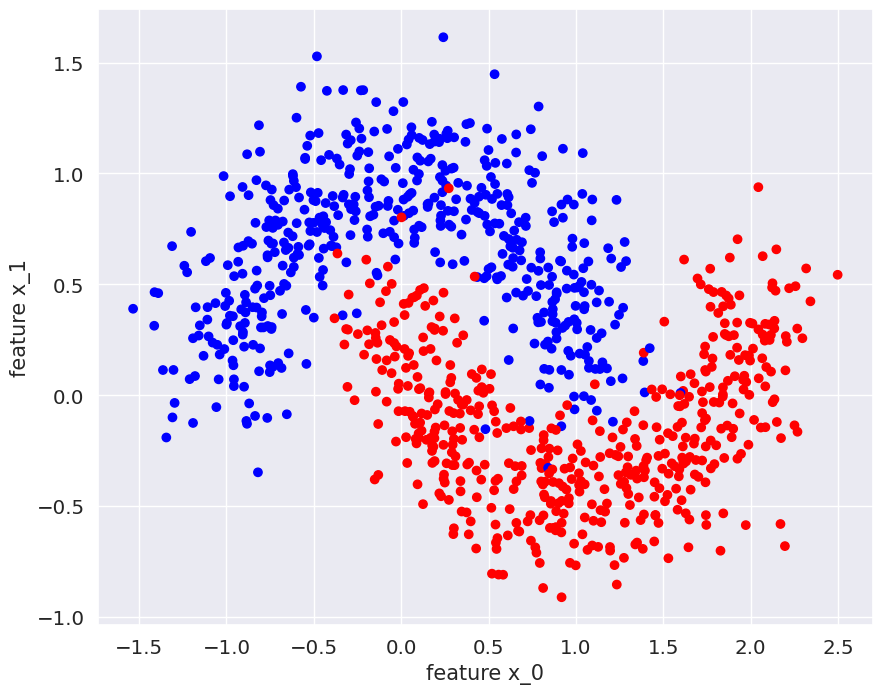

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# The artificial data will be taken from sklearn (make_moons)
from sklearn.datasets import make_moons

X, y = make_moons(n_samples = 1_000, noise = 0.20, random_state = 3)
colors = ["red" if label == 1 else "blue" for label in y]


plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], c = colors)
plt.xlabel("feature x_0", fontsize = 15)
plt.ylabel("feature x_1", fontsize = 15)
plt.grid(True)
plt.show()

Run the following code cell to create this split and to visualize the training data.


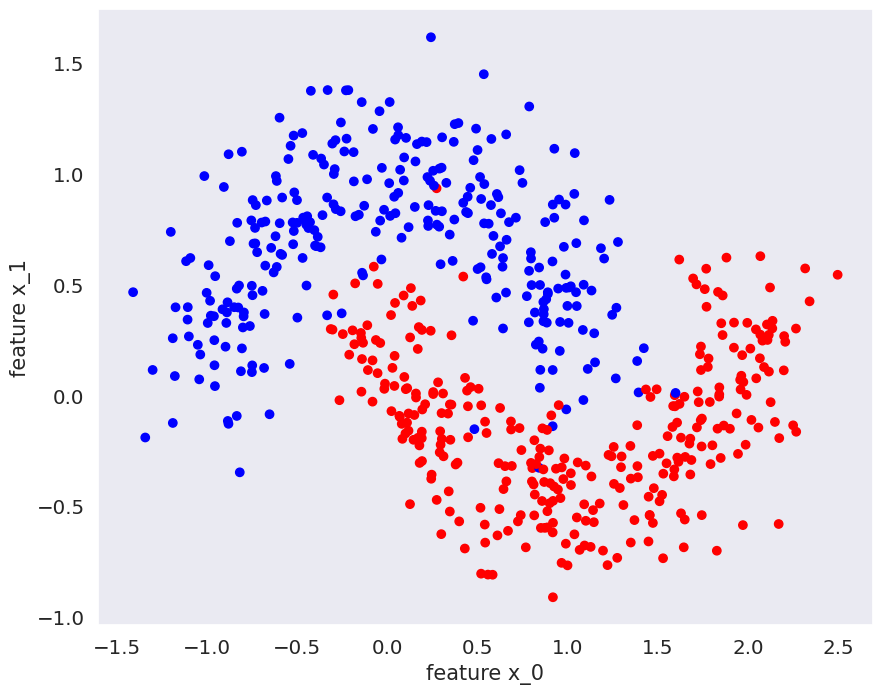

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.4,
                                                    random_state = 42)

c_train = ["red" if label == 1 else "blue" for label in y_train]
c_test = ["red" if label == 1 else "blue" for label in y_test]

plt.figure(figsize=(10, 8))
plt.scatter(X_train[:, 0], X_train[:, 1], c = c_train)
plt.xlabel("feature x_0", fontsize = 15)
plt.ylabel("feature x_1", fontsize = 15)
plt.grid()
plt.show()

Next we can train the model by calling the ```fit()``` method. Let's run the following code cell.

In [18]:
from sklearn.tree import DecisionTreeClassifier

# must create and train the model first!
decision_tree = DecisionTreeClassifier(max_depth=4, random_state=42)
decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

Also, we can visualize the tree structure of our current model by calling the ```sklearn.tree.plot_tree()``` function.

|--- x_1 <= 0.33
|   |--- x_0 <= -0.43
|   |   |--- class: 0
|   |--- x_0 >  -0.43
|   |   |--- x_1 <= 0.01
|   |   |   |--- x_1 <= -0.15
|   |   |   |   |--- class: 1
|   |   |   |--- x_1 >  -0.15
|   |   |   |   |--- class: 1
|   |   |--- x_1 >  0.01
|   |   |   |--- x_0 <= 0.57
|   |   |   |   |--- class: 1
|   |   |   |--- x_0 >  0.57
|   |   |   |   |--- class: 1
|--- x_1 >  0.33
|   |--- x_0 <= 1.45
|   |   |--- x_1 <= 0.58
|   |   |   |--- x_0 <= 0.45
|   |   |   |   |--- class: 0
|   |   |   |--- x_0 >  0.45
|   |   |   |   |--- class: 0
|   |   |--- x_1 >  0.58
|   |   |   |--- x_0 <= 0.27
|   |   |   |   |--- class: 0
|   |   |   |--- x_0 >  0.27
|   |   |   |   |--- class: 0
|   |--- x_0 >  1.45
|   |   |--- class: 1
 



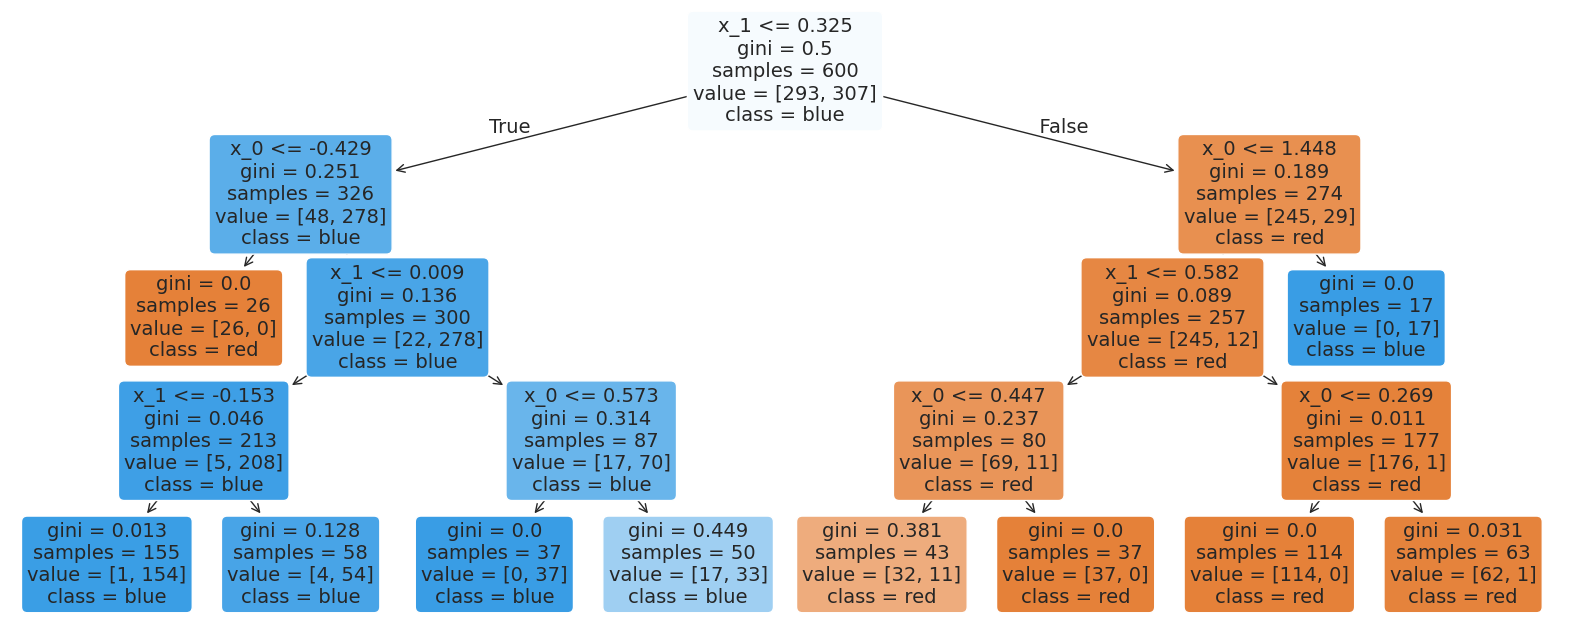

In [19]:
from sklearn.tree import plot_tree
from sklearn.tree import export_text

tree_rules = export_text(decision_tree,
                         feature_names = ["x_0", "x_1"])
print(tree_rules, "\n")


plt.figure(figsize=(20, 8))
a = plot_tree(decision_tree,
                   feature_names = ["x_0", "x_1"],
                   class_names = ["red", "blue"],
                   rounded = True,
                   filled = True,
                   fontsize=14)
plt.show()

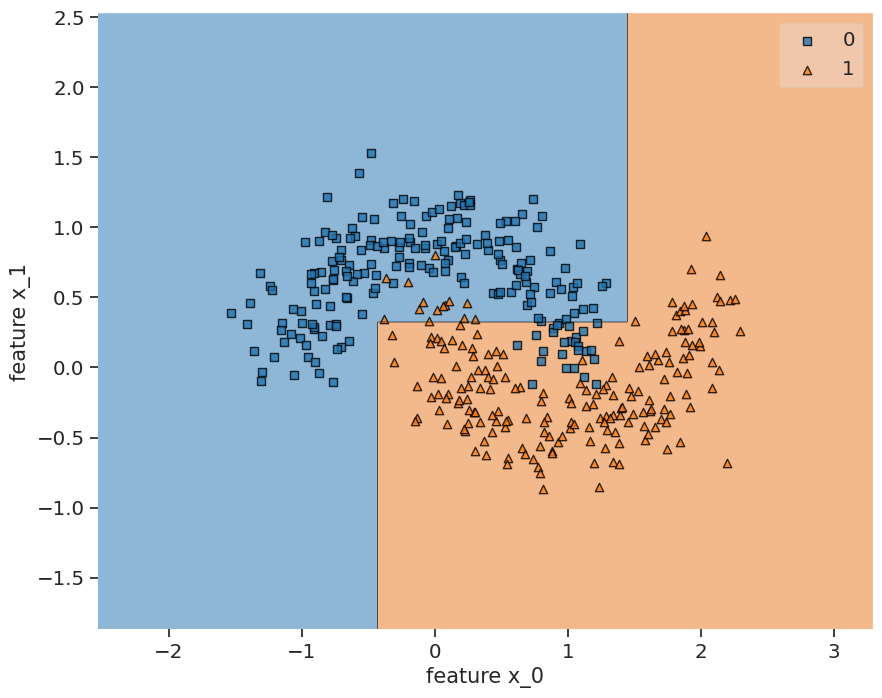

In [20]:
from mlxtend.plotting import plot_decision_regions

plt.figure(figsize = (10, 8))
plot_decision_regions(X_test, y_test, clf = decision_tree)
plt.xlabel("feature x_0", fontsize = 15)
plt.ylabel("feature x_1", fontsize = 15)
plt.grid()
plt.show()

Next, we can evaluate the models performance on the testing data

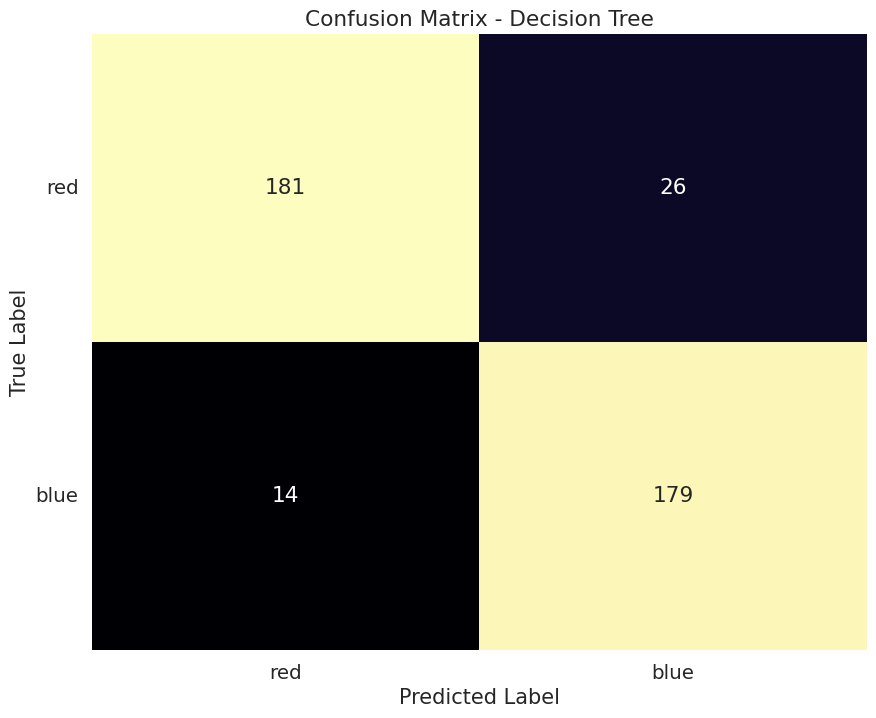

In [21]:
# predicted values on the testing data
test_pred_decision_tree = decision_tree.predict(X_test)

# Import metrics from sklearn
from sklearn import metrics

# Note: visualizing your tree above will be weird after running seaborn
import seaborn as sns

# The confusion matrix
confusion_matrix = metrics.confusion_matrix(y_test, test_pred_decision_tree)

# Convert confusion matrix into dataframe
matrix_df = pd.DataFrame(confusion_matrix)


plt.figure(figsize=(10, 8))
ax = plt.axes()
sns.set(font_scale=1.3)

sns.heatmap(matrix_df,
            annot = True,
            fmt = "g",
            ax = ax,
            cmap = "magma",
            cbar = False)

ax.set_title("Confusion Matrix - Decision Tree")
ax.set_xlabel("Predicted Label", fontsize=15)
ax.set_xticklabels(["red", "blue"])
ax.set_ylabel("True Label", fontsize=15)
ax.set_yticklabels(["red", "blue"], rotation=0)
plt.show()

In [22]:
from sklearn.metrics import classification_report

y_pred = decision_tree.predict(X_test)

#Checking performance our model with classification report.
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.87      0.90       207
           1       0.87      0.93      0.90       193

    accuracy                           0.90       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.90      0.90      0.90       400



### Regression Trees
Now we shift to predicting continuous values, the actual price of the house, rather than just a category. Instead of using entropy to find splits, regression trees look for the split that minimizes the Mean Squared Error (MSE), attempting to make the target values within each branch as similar as possible.

I will apply this to the California Housing dataset (housing.csv from Kaggle) to classify whether a home is "Expensive" (above median price) or "Affordable" based on its characteristics.

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing

# Target is median house value
X, y = fetch_california_housing(return_X_y = True)
X[0].shape
y[0]



np.float64(4.526)

In [24]:
from sklearn.tree import DecisionTreeRegressor
reg = DecisionTreeRegressor(max_depth=3)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 12)

reg.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=3)

In [25]:
from sklearn.metrics import mean_squared_error

reg1 = DecisionTreeRegressor(max_depth=1, random_state = 12)
reg1.fit(X_train, y_train)
y_pred = reg1.predict(X_test)
print(f"MSE reg1: {mean_squared_error(y_test, y_pred)} \n")


reg2 = DecisionTreeRegressor(max_depth=20, random_state = 12)
reg2.fit(X_train, y_train)
y_pred = reg2.predict(X_test)
print(f"MSE reg2: {mean_squared_error(y_test, y_pred)} \n")


MSE reg1: 0.9328869622627052 

MSE reg2: 0.5349058501336815 



In [26]:
reg1 = DecisionTreeRegressor(max_depth=1)
reg1.fit(X_train, y_train)
y_pred = reg1.predict(X_test)
print(f"MSE reg1: {mean_squared_error(y_test, y_pred)} \n")


reg2 = DecisionTreeRegressor(max_depth=20)
reg2.fit(X_train, y_train)
y_pred = reg2.predict(X_test)
print(f"MSE reg2: {mean_squared_error(y_test, y_pred)} \n")

MSE reg1: 0.932886962262705 

MSE reg2: 0.5206805358532992 



Overfitting vs. Underfitting

Overfitting: If we let a tree grow too deep (like max_depth=20), it may memorize the training data—including the noise—causing it to perform poorly on new data.

Underfitting: If the tree is too shallow (like max_depth=1), it might be too simple to capture the actual patterns, leading to low accuracy.

Using techniques like cross-validation can help find the optimal depth where the error is minimized.

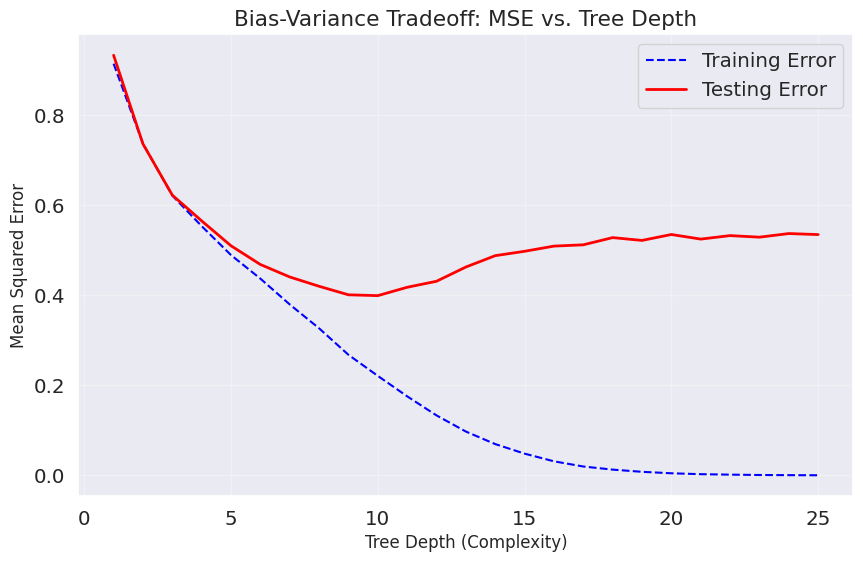

In [27]:
# 1. Setup range of depths to test
depths = range(1, 26)
training_mse = []
testing_mse = []

# 2. Loop through depths and record errors
for d in depths:
    # Use the Regressor since we are calculating MSE
    model = DecisionTreeRegressor(max_depth=d, random_state=12)
    model.fit(X_train, y_train)

    # Predict on both sets to see the 'gap'
    train_p = model.predict(X_train)
    test_p = model.predict(X_test)

    training_mse.append(mean_squared_error(y_train, train_p))
    testing_mse.append(mean_squared_error(y_test, test_p))

# 3. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(depths, training_mse, label='Training Error', color='blue', linestyle='--')
plt.plot(depths, testing_mse, label='Testing Error', color='red', linewidth=2)
plt.xlabel("Tree Depth (Complexity)", fontsize=12)
plt.ylabel("Mean Squared Error", fontsize=12)
plt.title("Bias-Variance Tradeoff: MSE vs. Tree Depth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

This plot illustrates the tradeoff for our decision tree model. As the Tree Depth increases, we observe the following:  

Initial Learning (Depth 1–8): Both the training (blue) and testing (red) errors drop significantly. The model is learning the actual underlying patterns of the housing data.  

The Optimal Point (around depth 9–10): The testing error reaches its lowest point (approximately 0.4 MSE) at a depth of 9 or 10. This is the optimal depth for our model because it provides the best generalization to new, unseen data.  
+1

Overfitting (Depth 11+): Beyond a depth of 10, the training error continues to plummet toward zero, but the testing error begins to climb back up.  

Conclusion: This 'gap' between the two lines shows that a very deep tree (like depth 25) has simply memorized the training set's noise. To ensure our model remains useful for real-world predictions, we should cap our depth at 10."  

Why this works:

In the Iris example from above earlier, the optimal depth was much lower because that dataset is very simple. For the Housing data, your plot proves that the relationship is more complex, requiring about levels of logic before it starts becoming "too smart' for its own good.